# Predicting Mental Health Recovery Trajectories in Longitudinal Forum Data
## An NLP and Machine Learning Framework

### Project by: Hari Prasad Rangaraj
### Supervised by: Dr Menasha Thilakaratne

## Importing the libraries

In [95]:
# Importing all the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import zipfile
import uuid
import re
import numpy as np
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Loading and exploring the Dataset

## Extracting the dataset

In [ ]:
dataset_zip = "dataset.zip"

with zipfile.ZipFile(dataset_zip, "r") as zip_ref:
    for member in zip_ref.infolist():
        # Skip directories and non-CSV files
        if member.is_dir() or not member.filename.endswith(".csv"):
            continue

        # Get just the file name and drop the folder path
        base_name = os.path.basename(member.filename)

        # Read the file data from the ZIP and write it to the current directory
        with zip_ref.open(member) as source, open(base_name, "wb") as target:
            target.write(source.read())

        print(f"Extracted the file: {base_name}")

Extracted the file: anxiety_comment.csv
Extracted the file: anxiety_post.csv
Extracted the file: depression_comment.csv
Extracted the file: depression_post.csv
Extracted the file: long-term-support-over-the-journey_comment.csv
Extracted the file: long-term-support-over-the-journey_post.csv
Extracted the file: ptsd-and-trauma_comment.csv
Extracted the file: ptsd-and-trauma_post.csv
Extracted the file: relationship-and-family-issues_comment.csv
Extracted the file: relationship-and-family-issues_post.csv
Extracted the file: staying-well_comment.csv
Extracted the file: staying-well_post.csv
Extracted the file: suicidal-thoughts-and-self-harm_comment.csv
Extracted the file: suicidal-thoughts-and-self-harm_post.csv
Extracted the file: supporting-family-and-friends_comment.csv
Extracted the file: supporting-family-and-friends_post.csv
Extracted the file: treatments-health-professionals_comment.csv
Extracted the file: treatments-health-professionals_post.csv


## Posts Dataset

In [50]:
# Find all the post files from the posts dataset in the current directory
all_post_files = glob.glob("*_post.csv")
all_post_files

['anxiety_post.csv',
 'depression_post.csv',
 'long-term-support-over-the-journey_post.csv',
 'ptsd-and-trauma_post.csv',
 'relationship-and-family-issues_post.csv',
 'staying-well_post.csv',
 'suicidal-thoughts-and-self-harm_post.csv',
 'supporting-family-and-friends_post.csv',
 'treatments-health-professionals_post.csv']

In [ ]:
post_list = []

for file in all_post_files:
    # Extract just the filename from the path
    filename = os.path.basename(file)
    
    # Strip the suffix to get the raw category name 
    # (e.g., 'treatments-health-professionals')
    category = filename.replace('_post.csv', '')
    
    # Read the CSV into a temporary dataframe
    df = pd.read_csv(file)
    
    # Inject the origin category as a new column
    df['Forum_Category'] = category
    
    # Create the globally unique Composite Key
    df['Composite_ID'] = df['Forum_Category'] + '_' + df['Post_ID'].astype(str)
    
    post_list.append(df)

# Combine all safely tagged dataframes into the master dataset
posts_df = pd.concat(post_list, ignore_index=True)

In [52]:
posts_df

,Post_ID,Post_Content,Post_Author,Post_Author_Rank,Post_Date,Post_Time,Post_Category,Number_of_Comments,Post_URL,Forum_Category,Composite_ID
0,1,"Hi everyone, I'm having a horrible week, so ju...",Whatsinaname,Community Member,‎25-09-2020,09:44 AM,Long-term support over the journey,76,/t5/anxiety/horrible-week/td-p/516409,anxiety,anxiety_1
1,2,Hi and best wishes to everyone..Im starting to...,Beaser,Community Member,‎21-05-2024,07:52 AM,Long-term support over the journey,15,/t5/anxiety/scared-again-and-dont-know-where-i...,anxiety,anxiety_2
2,3,So I have had experience with severe anxiety i...,Leslie,Community Member,‎15-06-2024,05:07 PM,Long-term support over the journey,12,/t5/anxiety/started-all-over-again/td-p/593538,anxiety,anxiety_3
3,4,"At times I tell my anxiety to stop, go away, l...",CMF,Blue Voices Member,‎10-04-2023,05:26 PM,Long-term support over the journey,36,/t5/anxiety/dear-anxiety/td-p/563084,anxiety,anxiety_4
4,5,"Hi everyone, I'm reaching out as something tha...",Wiltingdaisy,Community Member,‎18-06-2024,08:51 PM,Long-term support over the journey,10,/t5/anxiety/looking-for-tips-to-help-overcome-...,anxiety,anxiety_5
...,...,...,...,...,...,...,...,...,...,...,...
4730,192,Growing up I was always so cheerful and happy....,Tibby,Community Member,‎10-09-2013,09:28 PM,Long-term support over the journey,18,/t5/treatments-health-professionals/is-it-hard...,treatments-health-professionals,treatments-health-professionals_192
4731,193,We need to talk about this.,leon007,Community Member,‎29-08-2013,07:54 PM,Long-term support over the journey,16,/t5/treatments-health-professionals/side-effec...,treatments-health-professionals,treatments-health-professionals_193
4732,194,Well I finally got to see my new psychologist....,Marley,Community Member,‎26-06-2013,10:43 PM,Long-term support over the journey,10,/t5/treatments-health-professionals/new-psycho...,treatments-health-professionals,treatments-health-professionals_194
4733,195,I have just come home from my first psychologi...,bman42,Community Member,‎15-07-2013,09:27 PM,Long-term support over the journey,10,/t5/treatments-health-professionals/feel-frust...,treatments-health-professionals,treatments-health-professionals_195


In [53]:
# Read each file and combine them into the posts dataframe
posts_df = pd.concat((pd.read_csv(f) for f in all_post_files), ignore_index=True)

In [54]:
posts_df

,Post_ID,Post_Content,Post_Author,Post_Author_Rank,Post_Date,Post_Time,Post_Category,Number_of_Comments,Post_URL
0,1,"Hi everyone, I'm having a horrible week, so ju...",Whatsinaname,Community Member,‎25-09-2020,09:44 AM,Long-term support over the journey,76,/t5/anxiety/horrible-week/td-p/516409
1,2,Hi and best wishes to everyone..Im starting to...,Beaser,Community Member,‎21-05-2024,07:52 AM,Long-term support over the journey,15,/t5/anxiety/scared-again-and-dont-know-where-i...
2,3,So I have had experience with severe anxiety i...,Leslie,Community Member,‎15-06-2024,05:07 PM,Long-term support over the journey,12,/t5/anxiety/started-all-over-again/td-p/593538
3,4,"At times I tell my anxiety to stop, go away, l...",CMF,Blue Voices Member,‎10-04-2023,05:26 PM,Long-term support over the journey,36,/t5/anxiety/dear-anxiety/td-p/563084
4,5,"Hi everyone, I'm reaching out as something tha...",Wiltingdaisy,Community Member,‎18-06-2024,08:51 PM,Long-term support over the journey,10,/t5/anxiety/looking-for-tips-to-help-overcome-...
...,...,...,...,...,...,...,...,...,...
4730,192,Growing up I was always so cheerful and happy....,Tibby,Community Member,‎10-09-2013,09:28 PM,Long-term support over the journey,18,/t5/treatments-health-professionals/is-it-hard...
4731,193,We need to talk about this.,leon007,Community Member,‎29-08-2013,07:54 PM,Long-term support over the journey,16,/t5/treatments-health-professionals/side-effec...
4732,194,Well I finally got to see my new psychologist....,Marley,Community Member,‎26-06-2013,10:43 PM,Long-term support over the journey,10,/t5/treatments-health-professionals/new-psycho...
4733,195,I have just come home from my first psychologi...,bman42,Community Member,‎15-07-2013,09:27 PM,Long-term support over the journey,10,/t5/treatments-health-professionals/feel-frust...


In [55]:
unique_posts = posts_df['Post_ID'].nunique()
print(f"Number of unique posts in the posts dataset: {unique_posts}")

Number of unique posts in the posts dataset: 1446


In [56]:
unique_post_categories = posts_df['Post_Category'].nunique()
print(f"Number of unique post categories in the posts dataset: {unique_post_categories}")

Number of unique post categories in the posts dataset: 1


In [57]:
unique_post_authors = posts_df['Post_Author'].nunique()
print(f"Number of unique post authors in the posts dataset: {unique_post_authors}")

Number of unique post authors in the posts dataset: 2801


In [58]:
unique_post_author_rank = posts_df['Post_Author_Rank'].nunique()
print(f"Number of unique post author ranks in the posts dataset: {unique_post_author_rank}")

Number of unique post author ranks in the posts dataset: 7


In [59]:
posts_df.describe()

,Post_ID,Number_of_Comments
count,4735.000000,4735.000000
mean,428.560507,64.710032
std,364.746135,280.597446
min,1.000000,1.000000
25%,132.000000,12.000000
50%,312.000000,16.000000
75%,664.500000,42.000000
max,1446.000000,10746.000000


In [60]:
posts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4735 entries, 0 to 4734
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Post_ID             4735 non-null   int64 
 1   Post_Content        4734 non-null   object
 2   Post_Author         4735 non-null   object
 3   Post_Author_Rank    4735 non-null   object
 4   Post_Date           4735 non-null   object
 5   Post_Time           4735 non-null   object
 6   Post_Category       4735 non-null   object
 7   Number_of_Comments  4735 non-null   int64 
 8   Post_URL            4735 non-null   object
dtypes: int64(2), object(7)
memory usage: 333.1+ KB


## Comments Dataset

In [61]:
# Find all the comment files from the comments dataset in the current directory
all_comment_files = glob.glob("*_comment.csv")
all_comment_files

['anxiety_comment.csv',
 'depression_comment.csv',
 'long-term-support-over-the-journey_comment.csv',
 'ptsd-and-trauma_comment.csv',
 'relationship-and-family-issues_comment.csv',
 'staying-well_comment.csv',
 'suicidal-thoughts-and-self-harm_comment.csv',
 'supporting-family-and-friends_comment.csv',
 'treatments-health-professionals_comment.csv']

In [62]:
comment_list = []

for file in all_comment_files:
    filename = os.path.basename(file)
    category = filename.replace('_comment.csv', '')
    
    df = pd.read_csv(file)
    
    df['Forum_Category'] = category
    df['Composite_ID'] = df['Forum_Category'] + '_' + df['Post_ID'].astype(str)
    
    comment_list.append(df)

comments_df = pd.concat(comment_list, ignore_index=True)

In [63]:
comments_df

,Post_ID,Comment_ID,Comment_Content,Comment_Author,Comment_Date,Comment_Time,Forum_Category,Composite_ID
0,1,1,"Hey Whatsinaname, The shame spiral is such a g...",uncut_gems,25-09-2020,09:46 AM,anxiety,anxiety_1
1,1,2,"Hi Gems, Thanks for the reply. Depending on th...",Whatsinaname,25-09-2020,09:53 AM,anxiety,anxiety_1
2,1,3,"Hi Whatsinaname, Yes, get out if you can! It's...",uncut_gems,25-09-2020,01:57 PM,anxiety,anxiety_1
3,1,4,Thats good! I ended up cutting a sicky for th...,Whatsinaname,25-09-2020,02:34 PM,anxiety,anxiety_1
4,1,5,Aw I didn't know you had a son! It's good that...,uncut_gems,25-09-2020,03:19 PM,anxiety,anxiety_1
...,...,...,...,...,...,...,...,...
306329,196,4797,Originally posted by: Scotty on 30 October 201...,Bulletin_Board_Archive,30-10-2012,12:01 PM,treatments-health-professionals,treatments-health-professionals_196
306330,196,4798,Originally posted by: geoff on 1 November 2012...,Bulletin_Board_Archive,01-11-2012,02:45 AM,treatments-health-professionals,treatments-health-professionals_196
306331,196,4799,Originally posted by: scotty on 3 November 201...,Bulletin_Board_Archive,03-11-2012,03:44 PM,treatments-health-professionals,treatments-health-professionals_196
306332,196,4800,I went to a psychiatrist a few years ago as my...,tlrockliff,07-04-2013,02:05 AM,treatments-health-professionals,treatments-health-professionals_196


In [ ]:
# VERIFICATION
print(f"Total unique Composite IDs in Posts: {posts_df['Composite_ID'].nunique()}")
print(f"Total unique Composite IDs in Comments: {comments_df['Composite_ID'].nunique()}")

Total unique Composite IDs in Posts: 4735
Total unique Composite IDs in Comments: 4735


In [ ]:
print(f"{comments_df.index}")

RangeIndex(start=0, stop=306334, step=1)


In [ ]:
print(f"content:{comments_df.loc[306331]}")

content:Post_ID                                                          196
Comment_ID                                                      4799
Comment_Content    Originally posted by: scotty on 3 November 201...
Comment_Author                                Bulletin_Board_Archive
Comment_Date                                              03-11-2012
Comment_Time                                                03:44 PM
Forum_Category                       treatments-health-professionals
Composite_ID                     treatments-health-professionals_196
Name: 306331, dtype: object


In [ ]:
unique_comment_posts = comments_df['Post_ID'].nunique()
print(f"Number of unique posts that have comments in the comments dataset: {unique_comment_posts}")

Number of unique posts that have comments in the comments dataset: 1446


In [ ]:
unique_comments = comments_df['Comment_ID'].nunique()
print(f"Number of unique comments in the comments dataset: {unique_comments}")

Number of unique comments in the comments dataset: 103259


In [ ]:
unique_comment_content = comments_df['Comment_Content'].nunique()
print(f"Number of unique comment contents in the comments dataset: {unique_comment_content}")

Number of unique comment contents in the comments dataset: 220601


In [ ]:
unique_comment_authors = comments_df['Comment_Author'].nunique()
print(f"Number of unique comment authors in the comments dataset: {unique_comment_authors}")

Number of unique comment authors in the comments dataset: 8787


In [ ]:
comments_df.describe()

,Post_ID,Comment_ID
count,306334.000000,306334.000000
mean,318.773838,33403.759266
std,391.086894,27774.024405
min,1.000000,1.000000
25%,26.000000,9380.250000
50%,121.000000,25788.000000
75%,524.000000,53098.000000
max,1446.000000,103259.000000


In [ ]:
comments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306334 entries, 0 to 306333
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Post_ID          306334 non-null  int64 
 1   Comment_ID       306334 non-null  int64 
 2   Comment_Content  306334 non-null  object
 3   Comment_Author   306334 non-null  object
 4   Comment_Date     306334 non-null  object
 5   Comment_Time     306334 non-null  object
 6   Forum_Category   306334 non-null  object
 7   Composite_ID     306334 non-null  object
dtypes: int64(2), object(6)
memory usage: 18.7+ MB


## Dataset Exploration and depiction

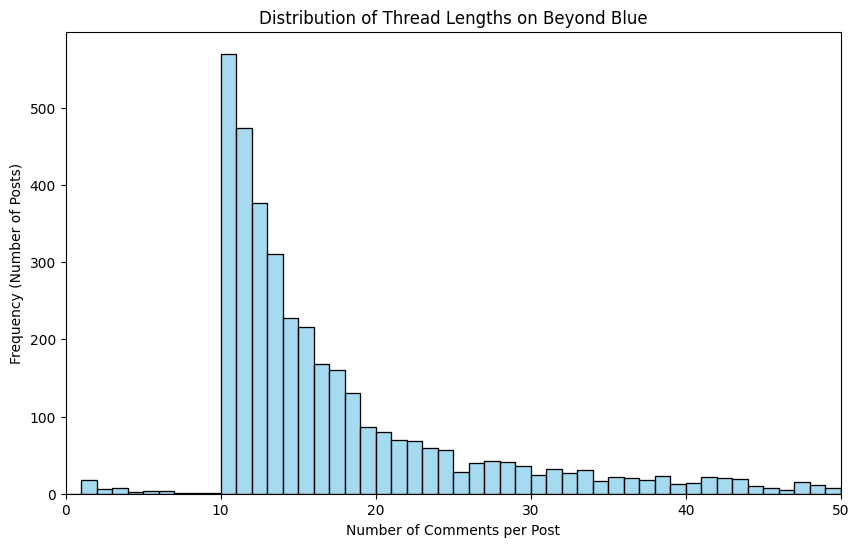

In [ ]:
# Force the column to be numeric, turning any weird text/blanks into 0
posts_df['Number_of_Comments'] = pd.to_numeric(posts_df['Number_of_Comments'], errors='coerce').fillna(0)

# Re-plot with explicit, discrete bins (1, 2, 3, etc.)
plt.figure(figsize=(10, 6))
sns.histplot(posts_df['Number_of_Comments'], bins=range(0, 55, 1), color='skyblue')
plt.title('Distribution of Thread Lengths on Beyond Blue')
plt.xlabel('Number of Comments per Post')
plt.ylabel('Frequency (Number of Posts)')
plt.xlim(0, 50)
plt.show()

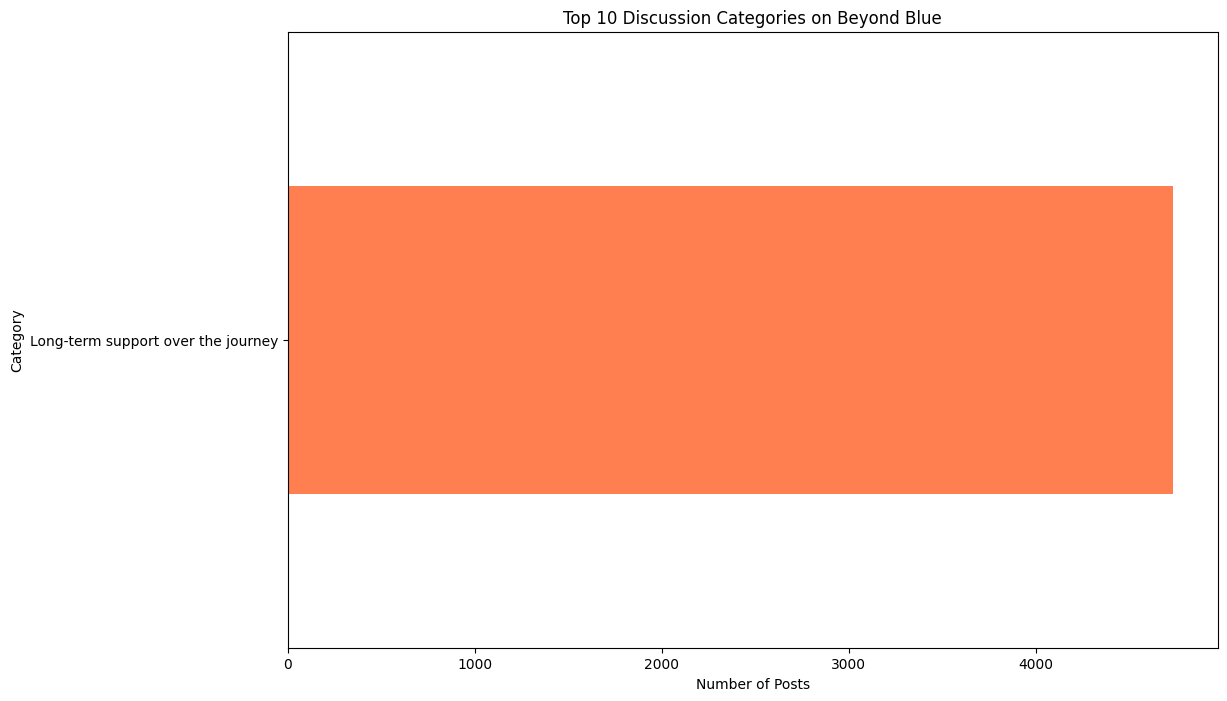

In [ ]:
plt.figure(figsize=(12, 8))
posts_df['Post_Category'].value_counts().head(10).plot(kind='barh', color='coral')
plt.title('Top 10 Discussion Categories on Beyond Blue')
plt.xlabel('Number of Posts')
plt.ylabel('Category')
plt.gca().invert_yaxis() # Puts the highest value at the top
plt.show()

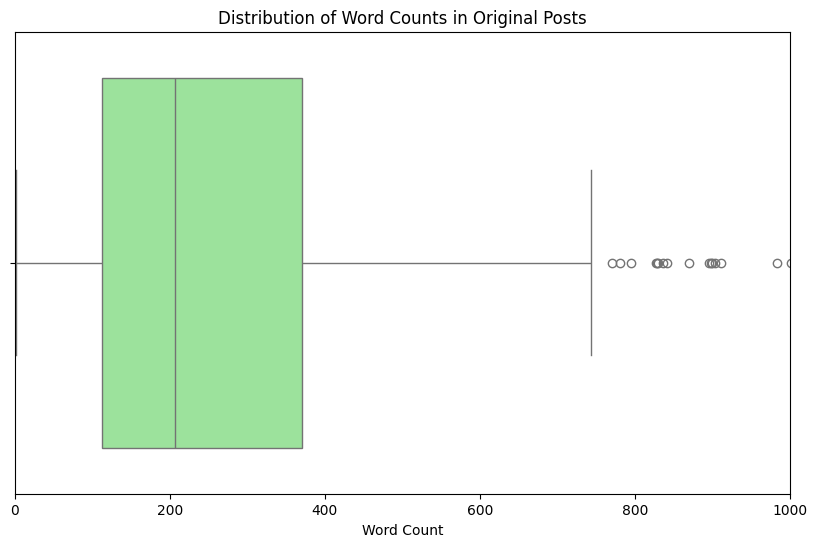

In [65]:
# Create a word count column
posts_df['word_count'] = posts_df['Post_Content'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.boxplot(x=posts_df['word_count'], color='lightgreen')
plt.title('Distribution of Word Counts in Original Posts')
plt.xlabel('Word Count')
plt.xlim(0, 1000) # Cut off extreme outliers for a cleaner chart
plt.show()

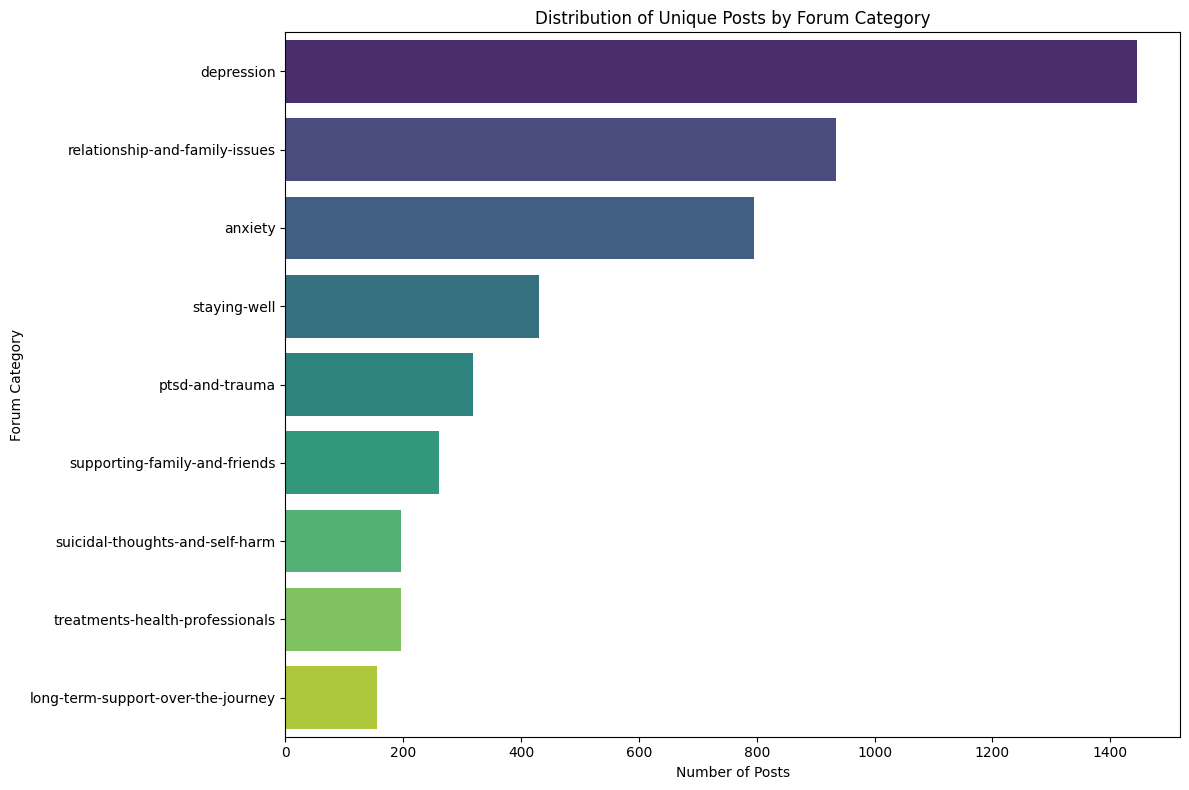

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your posts_df now has the 'Forum_Category' column
plt.figure(figsize=(12, 8))
# Get top 15 categories to keep the chart readable
category_counts = posts_df['Forum_Category'].value_counts().head(15)

sns.barplot(x=category_counts.values, y=category_counts.index, hue=category_counts.index, legend=False, palette='viridis')
plt.title('Distribution of Unique Posts by Forum Category')
plt.xlabel('Number of Posts')
plt.ylabel('Forum Category')
plt.tight_layout()
plt.show()

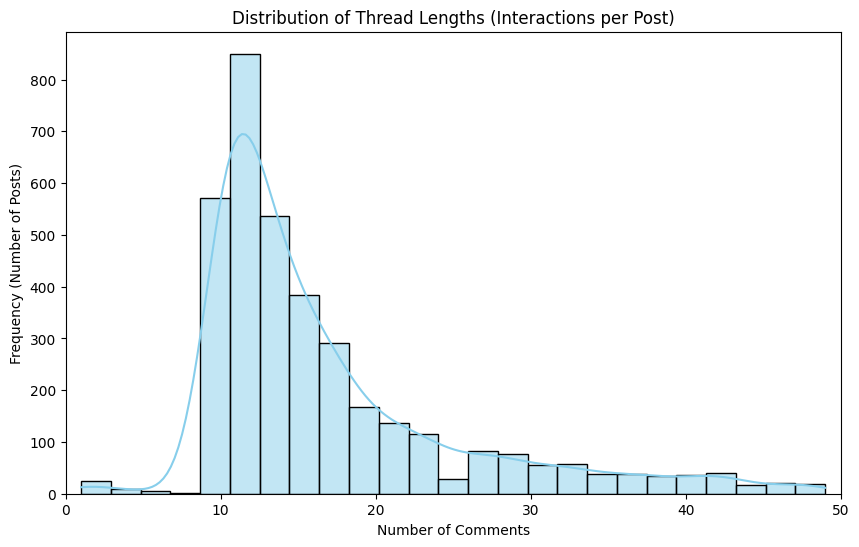

In [67]:
plt.figure(figsize=(10, 6))
# Filter out extreme outliers (e.g., threads with 500+ comments) just for a cleaner visual
sns.histplot(posts_df[posts_df['Number_of_Comments'] < 50]['Number_of_Comments'], 
             bins=25, color='skyblue', kde=True)
plt.title('Distribution of Thread Lengths (Interactions per Post)')
plt.xlabel('Number of Comments')
plt.ylabel('Frequency (Number of Posts)')
plt.xlim(0, 50)
plt.show()

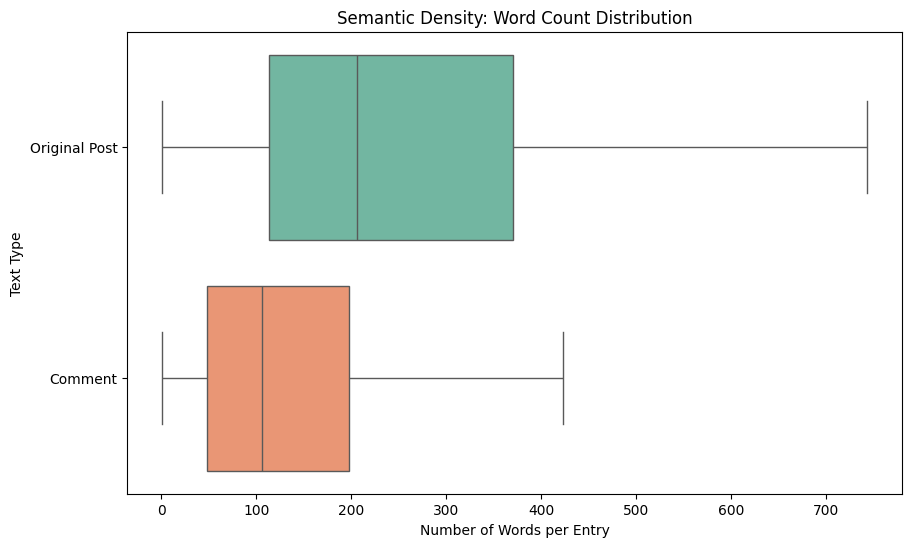

In [68]:
# Create temporary columns just for plotting
posts_df['word_count'] = posts_df['Post_Content'].astype(str).apply(lambda x: len(x.split()))
# Take a random sample of comments so the plotting doesn't crash your computer
sampled_comments = comments_df.sample(n=min(50000, len(comments_df)), random_state=42)
sampled_comments['word_count'] = sampled_comments['Comment_Content'].astype(str).apply(lambda x: len(x.split()))

# Combine for plotting
plot_data = pd.DataFrame({
    'Text Type': ['Original Post'] * len(posts_df) + ['Comment'] * len(sampled_comments),
    'Word Count': list(posts_df['word_count']) + list(sampled_comments['word_count'])
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Word Count', y='Text Type', data=plot_data, palette='Set2',hue='Text Type', showfliers=False)
plt.title('Semantic Density: Word Count Distribution')
plt.xlabel('Number of Words per Entry')
plt.show()

## Indentifying issues with the current dataset

In [88]:
id_934_view = posts_df[posts_df['Post_ID'] == 934][['Post_ID', 'Post_Author', 'Post_Date', 'Post_Content']]
print(id_934_view.head())

      Post_ID  Post_Author    Post_Date  \
1728      934  Dorian_Gray  ‎20-10-2016   
3648      934   Draconhart  ‎09-08-2013   

                                           Post_Content  
1728  About a month ago an opportunity for a promoti...  
3648  Where to start. There is a bit to my story... ...  


## Cleaning the dataset

In [70]:
# We now define a duplicate as having the exact same Author, Date, and Content
composite_subset = ['Post_Author', 'Post_Date', 'Post_Content']

true_duplicates_count = posts_df.duplicated(subset=composite_subset).sum()
print(f"\nTotal TRUE duplicate rows identified: {true_duplicates_count}")
print(f"Total rows before cleaning: {len(posts_df)}")


Total TRUE duplicate rows identified: 631
Total rows before cleaning: 4735


In [71]:
# Drop the true duplicates based on our composite subset
posts_df_clean = posts_df.drop_duplicates(subset=composite_subset, keep='first')

print(f"Total rows after removing true duplicates: {len(posts_df_clean)}")

Total rows after removing true duplicates: 4104


In [72]:
# Overwrite your original dataframe variable
posts_df = posts_df_clean.copy()

In [ ]:
# Isolate the unique Post_IDs from the comments
unique_comment_post_ids = comments_df['Post_ID'].unique()
print(f"Number of unique Post_IDs in comments: {len(unique_comment_post_ids)}")

# Project the mapping: Filter posts_df to only include these IDs
# We use .isin() to check if the posts's ID exists in our comments list
mapped_posts_df = posts_df[posts_df['Post_ID'].isin(unique_comment_post_ids)]

# Results
print(f"Total rows in posts dataset that map to these comments: {len(mapped_posts_df)}")
print(f"Total unique IDs within those mapped rows: {mapped_posts_df['Post_ID'].nunique()}")

Number of unique Post_IDs in comments: 1446
Total rows in posts dataset that map to these comments: 4104
Total unique IDs within those mapped rows: 1250


In [ ]:
# REMOVE EXACT CLONES
# Define a true duplicate as having the exact same Author, Date, and Content
composite_subset = ['Post_Author', 'Post_Date', 'Post_Content']
posts_df_clean = posts_df.drop_duplicates(subset=composite_subset, keep='first')
posts_df = posts_df_clean.copy()

print(f"Total unique posts after removing exact clones: {len(posts_df)}")

# GENERATE SURROGATE KEYS
# Create a unique True_Thread_ID for every valid post so we can safely identify them later
posts_df['True_Thread_ID'] = [str(uuid.uuid4()) for _ in range(len(posts_df))]

# PREPARE TIMESTAMPS
# Convert string dates to datetime objects for mathematical comparison
# Format assumes 'DD-MM-YYYY HH:MM AM/PM' 
posts_df['Post_Datetime'] = pd.to_datetime(posts_df['Post_Date'] + ' ' + posts_df['Post_Time'], format='%d-%m-%Y %I:%M %p', errors='coerce')
comments_df['Comment_Datetime'] = pd.to_datetime(comments_df['Comment_Date'] + ' ' + comments_df['Comment_Time'], format='%d-%m-%Y %I:%M %p', errors='coerce')

# THE CARTESIAN MERGE
# Merge on the flawed Post_ID (This will intentionally create temporary duplicates)
merged_df = pd.merge(
    comments_df, 
    posts_df[['Post_ID', 'True_Thread_ID', 'Post_Datetime']], 
    on='Post_ID', 
    how='inner'
)

# TEMPORAL FILTERING (THE LOGIC GATE)
# Drop rows where the comment mathematically happened BEFORE the post was created
valid_links = merged_df[merged_df['Comment_Datetime'] >= merged_df['Post_Datetime']].copy()

# Calculate time difference to find the closest preceding post
valid_links['Time_Difference'] = valid_links['Comment_Datetime'] - valid_links['Post_Datetime']

# Group by Comment_ID and keep only the row with the smallest time difference
final_mapped_comments = valid_links.loc[valid_links.groupby('Comment_ID')['Time_Difference'].idxmin()]

# Clean up the dataframe by dropping the temporary columns used for math
final_mapped_comments = final_mapped_comments.drop(columns=['Post_Datetime', 'Time_Difference'])

print(f"Original comments count: {len(comments_df)}")
print(f"Final successfully mapped comments: {len(final_mapped_comments)}")

Total unique posts after removing exact clones: 4104
Original comments count: 306334
Final successfully mapped comments: 0


In [83]:
import pandas as pd

# CLEAN THE STRINGS 
# Strip hidden whitespaces and convert to standard strings
post_datetime_str = posts_df['Post_Date'].astype(str).str.strip() + ' ' + posts_df['Post_Time'].astype(str).str.strip()
comment_datetime_str = comments_df['Comment_Date'].astype(str).str.strip() + ' ' + comments_df['Comment_Time'].astype(str).str.strip()

# FLEXIBLE PARSING 
# Use dayfirst=True (Australian standard) but let Pandas figure out the exact spacing
posts_df['Post_Datetime'] = pd.to_datetime(
    post_datetime_str,
    format='%d/%m/%Y %H:%M:%S',
    dayfirst=True,
    errors='coerce'
)
comments_df['Comment_Datetime'] = pd.to_datetime(
    comment_datetime_str,
    format='%d/%m/%Y %H:%M:%S',
    dayfirst=True,
    errors='coerce'
)

# DIAGNOSTIC CHECK
# If these numbers are high, the dates are severely corrupted in the raw data
print(f"Failed Post Datetimes (NaT): {posts_df['Post_Datetime'].isna().sum()} out of {len(posts_df)}")
print(f"Failed Comment Datetimes (NaT): {comments_df['Comment_Datetime'].isna().sum()} out of {len(comments_df)}")

# RE-RUN THE MERGE & FILTER
# Only proceed if the dates actually parsed
if posts_df['Post_Datetime'].isna().sum() < len(posts_df):
    merged_df = pd.merge(
        comments_df, 
        posts_df[['Post_ID', 'True_Thread_ID', 'Post_Datetime']], 
        on='Post_ID', 
        how='inner'
    )

    # The Logic Gate
    valid_links = merged_df[merged_df['Comment_Datetime'] >= merged_df['Post_Datetime']].copy()

    # The Tie-Breaker
    valid_links['Time_Difference'] = valid_links['Comment_Datetime'] - valid_links['Post_Datetime']
    final_mapped_comments = valid_links.loc[valid_links.groupby('Comment_ID')['Time_Difference'].idxmin()]
    final_mapped_comments = final_mapped_comments.drop(columns=['Post_Datetime', 'Time_Difference'])

    print(f"Original comments count: {len(comments_df)}")
    print(f"Final successfully mapped comments: {len(final_mapped_comments)}")
else:
    print("\nCRITICAL ERROR: All dates failed to parse. We need to inspect the raw date strings.")

Failed Post Datetimes (NaT): 4735 out of 4735
Failed Comment Datetimes (NaT): 306334 out of 306334

CRITICAL ERROR: All dates failed to parse. We need to inspect the raw date strings.


## Further issues found, fixing the dataset

In [84]:
# Isolate the rows where the datetime conversion failed
failed_dates_df = posts_df[posts_df['Post_Datetime'].isna()]

# Print the raw, original strings so we can see what the scraper actually grabbed
print("Raw Text of Failing Post Dates")
print(failed_dates_df[['Post_Date', 'Post_Time']].head(20))

Raw Text of Failing Post Dates
      Post_Date Post_Time
0   ‎25-09-2020  09:44 AM
1   ‎21-05-2024  07:52 AM
2   ‎15-06-2024  05:07 PM
3   ‎10-04-2023  05:26 PM
4   ‎18-06-2024  08:51 PM
5   ‎11-11-2020  07:52 AM
6   ‎19-02-2024  04:21 PM
7   ‎07-01-2021  02:48 PM
8   ‎01-10-2022  06:47 AM
9   ‎08-05-2024  12:18 PM
10  ‎14-04-2024  01:47 PM
11  ‎10-12-2023  10:27 PM
12  ‎08-03-2024  10:00 PM
13  ‎09-02-2020  04:11 PM
14  ‎22-05-2019  11:11 AM
15  ‎23-03-2024  03:38 PM
16  ‎03-11-2023  07:43 PM
17  ‎18-02-2024  07:35 PM
18  ‎17-02-2024  09:08 AM
19  ‎24-02-2024  07:04 AM


In [89]:
import pandas as pd
import uuid

# THE INVISIBLE CHARACTER SCRUB
# Use regex to strip out ANY non-standard ASCII unicode characters (the invisible ghosts)
posts_df['Post_Date'] = posts_df['Post_Date'].astype(str).str.replace(r'[^\x00-\x7F]+', '', regex=True).str.strip()
posts_df['Post_Time'] = posts_df['Post_Time'].astype(str).str.replace(r'[^\x00-\x7F]+', '', regex=True).str.strip()
posts_df['True_Thread_ID'] = [str(uuid.uuid4()) for _ in range(len(posts_df))]
comments_df['Comment_Date'] = comments_df['Comment_Date'].astype(str).str.replace(r'[^\x00-\x7F]+', '', regex=True).str.strip()
comments_df['Comment_Time'] = comments_df['Comment_Time'].astype(str).str.replace(r'[^\x00-\x7F]+', '', regex=True).str.strip()

# RE-BUILD THE DATETIME STRINGS
post_datetime_str = posts_df['Post_Date'] + ' ' + posts_df['Post_Time']
comment_datetime_str = comments_df['Comment_Date'] + ' ' + comments_df['Comment_Time']

# FLEXIBLE PARSING
posts_df['Post_Datetime'] = pd.to_datetime(post_datetime_str, dayfirst=True, errors='coerce')
comments_df['Comment_Datetime'] = pd.to_datetime(comment_datetime_str, dayfirst=True, errors='coerce')

# DIAGNOSTIC CHECK
print("Datetime Conversion Check")
print(f"Failed Post Datetimes (NaT): {posts_df['Post_Datetime'].isna().sum()} out of {len(posts_df)}")
print(f"Failed Comment Datetimes (NaT): {comments_df['Comment_Datetime'].isna().sum()} out of {len(comments_df)}")

# THE MERGE & TEMPORAL DISAMBIGUATION 
# (Only running if the dates actually parsed this time!)
if posts_df['Post_Datetime'].isna().sum() < len(posts_df):
    merged_df = pd.merge(
        comments_df, 
        posts_df[['Post_ID', 'True_Thread_ID', 'Post_Datetime']], 
        on='Post_ID', 
        how='inner'
    )

    valid_links = merged_df[merged_df['Comment_Datetime'] >= merged_df['Post_Datetime']].copy()
    valid_links['Time_Difference'] = valid_links['Comment_Datetime'] - valid_links['Post_Datetime']
    
    final_mapped_comments = valid_links.loc[valid_links.groupby('Comment_ID')['Time_Difference'].idxmin()]
    final_mapped_comments = final_mapped_comments.drop(columns=['Post_Datetime', 'Time_Difference'])

    print("\nResults")
    print(f"Original comments count: {len(comments_df)}")
    print(f"Final successfully mapped comments: {len(final_mapped_comments)}")

Datetime Conversion Check
Failed Post Datetimes (NaT): 4 out of 4735
Failed Comment Datetimes (NaT): 495 out of 306334

Results
Original comments count: 306334
Final successfully mapped comments: 103259


## Merging the Datasets

In [92]:
# INGEST & TAG POSTS
all_post_files = glob.glob("*_post.csv")
post_list = []

for file in all_post_files:
    category = os.path.basename(file).replace('_post.csv', '')
    df = pd.read_csv(file)
    df['Forum_Category'] = category
    df['Composite_ID'] = df['Forum_Category'] + '_' + df['Post_ID'].astype(str)
    post_list.append(df)

posts_df = pd.concat(post_list, ignore_index=True)
print(f"Ingested {len(posts_df)} total posts across {len(all_post_files)} categories.")

# INGEST & TAG COMMENTS
all_comment_files = glob.glob("*_comment.csv")
comment_list = []

for file in all_comment_files:
    category = os.path.basename(file).replace('_comment.csv', '')
    df = pd.read_csv(file)
    df['Forum_Category'] = category
    df['Composite_ID'] = df['Forum_Category'] + '_' + df['Post_ID'].astype(str)
    comment_list.append(df)

comments_df = pd.concat(comment_list, ignore_index=True)
print(f"Ingested {len(comments_df)} total comments.")

# THE RELATIONAL MERGE
# We merge on the new Composite_ID to prevent the Cartesian explosion
# We only bring over the necessary columns from posts_df to keep the dataset clean
merged_df = pd.merge(
    comments_df, 
    posts_df[['Composite_ID', 'Post_Content', 'Post_Author', 'Post_Date', 'Post_Time']], 
    on='Composite_ID', 
    how='inner'
)
print(f"Successfully merged into {len(merged_df)} chronological thread interactions.")

# BASIC NLP TEXT CLEANING
# To prepare for your VADER sentiment analysis and Random Forest later, 
# we need to strip out HTML tags, newline characters, and forum artifacts.
def clean_text(text):
    text = str(text)
    text = re.sub(r'<[^>]+>', '', text) # Remove HTML tags
    text = re.sub(r'\n|\r', ' ', text)  # Remove newlines
    text = re.sub(r'\s+', ' ', text)    # Condense multiple spaces into one
    return text.strip()

merged_df['Clean_Comment_Content'] = merged_df['Comment_Content'].apply(clean_text)
merged_df['Clean_Post_Content'] = merged_df['Post_Content'].apply(clean_text)

# EXPORT FINAL DATASET
export_name = "BeyondBlue_Master_Preprocessed.csv"
merged_df.to_csv(export_name, index=False)

Ingested 4735 total posts across 9 categories.
Ingested 306334 total comments.
Successfully merged into 306334 chronological thread interactions.


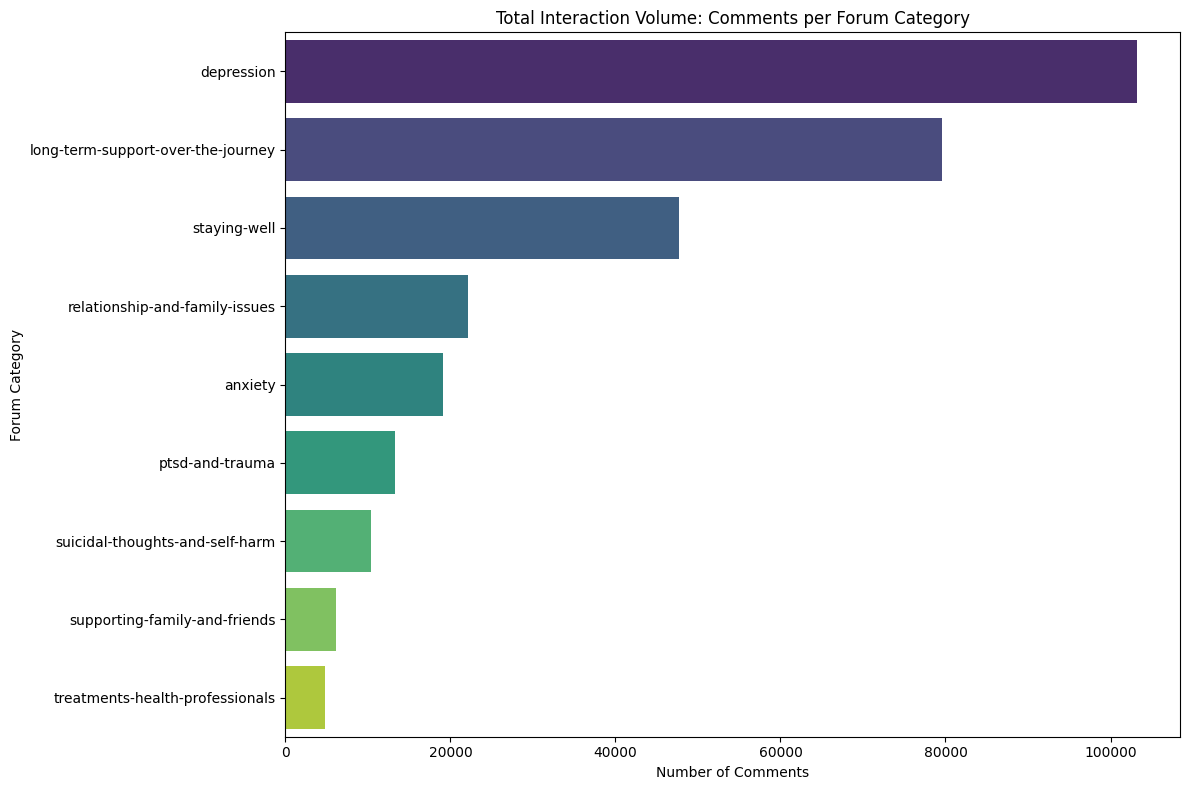

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of verified comments in each category
plt.figure(figsize=(12, 8))
comment_counts = merged_df['Forum_Category'].value_counts().head(15)

# Create the horizontal bar chart matching your previous aesthetic
sns.barplot(x=comment_counts.values, y=comment_counts.index, legend=False, hue=comment_counts.index, palette='viridis')

# Update the titles and labels
plt.title('Total Interaction Volume: Comments per Forum Category')
plt.xlabel('Number of Comments')
plt.ylabel('Forum Category')
plt.tight_layout()
plt.show()

## Implementing VADER

In [94]:
# Downloading VADER
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# FIX DATES & SORT CHRONOLOGICALLY
# We must scrub the invisible HTML ghost characters again just for the comments to ensure perfect sorting
merged_df['Comment_Date'] = merged_df['Comment_Date'].astype(str).str.replace(r'[^\x00-\x7F]+', '', regex=True).str.strip()
merged_df['Comment_Time'] = merged_df['Comment_Time'].astype(str).str.replace(r'[^\x00-\x7F]+', '', regex=True).str.strip()

# Convert to datetime and sort so comment #1 is actually first
merged_df['Comment_Datetime'] = pd.to_datetime(merged_df['Comment_Date'] + ' ' + merged_df['Comment_Time'], dayfirst=True, errors='coerce')
merged_df = merged_df.sort_values(by=['Composite_ID', 'Comment_Datetime'])

# GENERATE TARGET LABELS (y) FROM POST-SLICE
def get_vader_score(text):
    return sia.polarity_scores(str(text))['compound']

# SEPARATE PRE-SLICE AND POST-SLICE
# We will use the first 5 comments as the early warning signs (pre-slice)
N_COMMENTS = 5
merged_df['Comment_Rank'] = merged_df.groupby('Composite_ID').cumcount() + 1

pre_slice_df = merged_df[merged_df['Comment_Rank'] <= N_COMMENTS]
post_slice_df = merged_df.loc[merged_df['Comment_Rank'] > N_COMMENTS].copy()
post_slice_df.loc[:, 'Sentiment'] = post_slice_df['Clean_Comment_Content'].apply(get_vader_score)

# Calculate sentiment for the later comments to see how the thread ended
post_slice_df['Sentiment'] = post_slice_df['Clean_Comment_Content'].apply(get_vader_score)
thread_outcomes = post_slice_df.groupby('Composite_ID')['Sentiment'].mean().reset_index()

# Apply the heuristic: Positive end = Improved, Negative end = Worsened
def label_trajectory(score):
    if score > 0.05: return 'Improved'
    elif score < -0.05: return 'Worsened'
    else: return 'Stable'

thread_outcomes['Trajectory_Label'] = thread_outcomes['Sentiment'].apply(label_trajectory)

# EXTRACT FEATURES (X) FROM PRE-SLICE
def count_pronouns(text):
    text = str(text).lower()
    singular = len(re.findall(r'\b(i|me|my|mine|myself)\b', text))
    plural = len(re.findall(r'\b(we|us|our|ours|ourselves)\b', text))
    return pd.Series({'Singular_Pronouns': singular, 'Plural_Pronouns': plural})

# Condense the first 5 comments into one block of text per thread
pre_slice_features = pre_slice_df.groupby('Composite_ID')['Clean_Comment_Content'].apply(lambda x: ' '.join(map(str, x))).reset_index()

# Count the pronouns in those early comments
pronoun_counts = pre_slice_features['Clean_Comment_Content'].apply(count_pronouns)
pre_slice_features = pd.concat([pre_slice_features, pronoun_counts], axis=1)

# ASSEMBLE THE FINAL ML TABULAR DATASET
ml_dataset = pd.merge(pre_slice_features, thread_outcomes[['Composite_ID', 'Trajectory_Label']], on='Composite_ID', how='inner')

print(f"Total fully processed threads ready for ML: {len(ml_dataset)}")
print(ml_dataset[['Composite_ID', 'Singular_Pronouns', 'Plural_Pronouns', 'Trajectory_Label']].head())

Total fully processed threads ready for ML: 4698
  Composite_ID  Singular_Pronouns  Plural_Pronouns Trajectory_Label
0    anxiety_1                 17                0         Improved
1   anxiety_10                 21               16         Improved
2  anxiety_100                 36               15         Improved
3  anxiety_101                 31               15         Improved
4  anxiety_102                 18                2         Improved


## Implement the Random Forest Classifier Model

Training on 3758 threads, Testing on 940 threads.
Overall Accuracy: 0.788

Detailed Classification Report:
              precision    recall  f1-score   support

    Improved       0.92      0.85      0.88       865
      Stable       0.02      0.03      0.02        29
    Worsened       0.01      0.02      0.02        46

    accuracy                           0.79       940
   macro avg       0.32      0.30      0.31       940
weighted avg       0.84      0.79      0.82       940



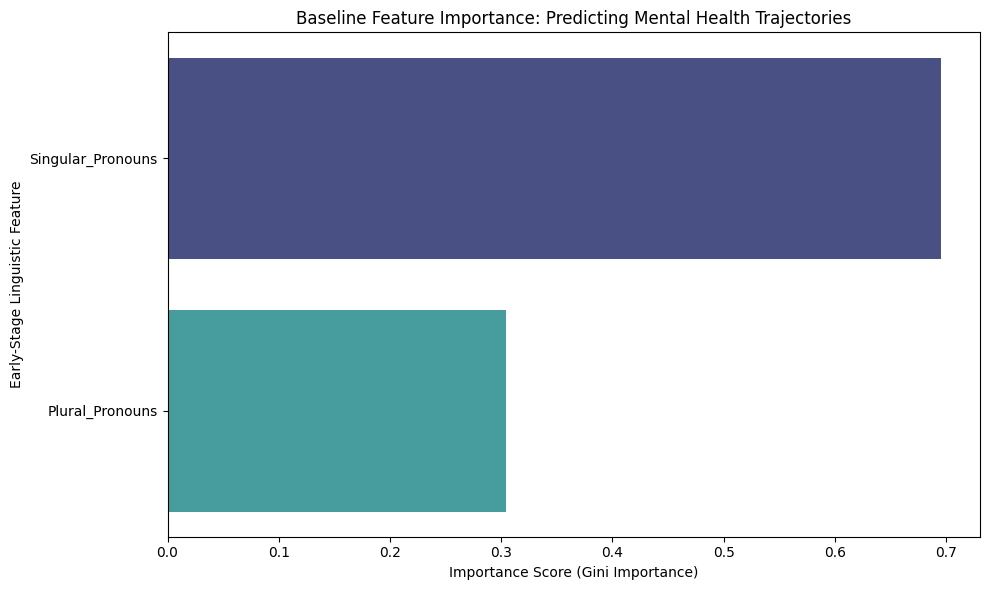

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

#DEFINE FEATURES (X) AND TARGET (y)
# Drop the ID and the target label to isolate the numerical features
columns_to_drop = ['Composite_ID', 'Trajectory_Label']
if 'Clean_Comment_Content' in ml_dataset.columns:
    columns_to_drop.append('Clean_Comment_Content')

X = ml_dataset.drop(columns=columns_to_drop)
y = ml_dataset['Trajectory_Label']

# TRAIN/TEST SPLIT
# We use stratify=y to ensure the 80/20 split maintains the same ratio of 
# Improved/Worsened/Stable in both the training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training on {len(X_train)} threads, Testing on {len(X_test)} threads.")

# INITIALIZE AND TRAIN THE MODEL
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# MAKE PREDICTIONS
y_pred = rf_model.predict(X_test)

# EVALUATE THE MODEL
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# FEATURE IMPORTANCE CHART 
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='mako', hue=feature_importances.index, legend=False)
plt.title('Baseline Feature Importance: Predicting Mental Health Trajectories')
plt.xlabel('Importance Score (Gini Importance)')
plt.ylabel('Early-Stage Linguistic Feature')
plt.tight_layout()
plt.show()